# NYC Citi Bike Trip

### Part 1 - Data Collection

In [26]:
# Import Libraries

import os
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Create Project Folders

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/external", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [28]:
# Download Citi Bike Data

year = 2024
month = 1

url = f"https://s3.amazonaws.com/tripdata/{year}{month:02d}-citibike-tripdata.zip"

response = requests.get(url)

print("Status Code:", response.status_code)
print("Content Type:", response.headers.get("Content-Type"))
print("File Size:", len(response.content), "bytes")

Status Code: 200
Content Type: application/zip
File Size: 369035302 bytes


In [29]:
# Save ZIP File

zip_path = f"data/raw/{year}{month:02d}-citibike-tripdata.zip"

with open(zip_path, "wb") as file:
    file.write(response.content)

print("File downloaded successfully")

File downloaded successfully


In [30]:
# Check ZIP File

print("Is valid ZIP:", zipfile.is_zipfile(zip_path))

Is valid ZIP: True


In [31]:
# Extract ZIP File

with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall("data/raw")

print("ZIP file extracted successfully")

ZIP file extracted successfully


In [32]:
# Find CSV File

files = os.listdir("data/raw")

csv_files = []

for file in files:
    if file.endswith(".csv"):
        csv_files.append(file)

print(csv_files)

['202401-citibike-tripdata_1.csv', '202401-citibike-tripdata_2.csv']


In [33]:
# Read CSV File

csv_path = "data/raw/" + csv_files[0]

df = pd.read_csv(csv_path)

print("Data loaded successfully")
print("Shape:", df.shape)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11140\2485672392.py:5: DtypeWarning: Columns (0: start_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Data loaded successfully
Shape: (1000000, 13)


### Part 2 - Data Cleaning

In [34]:
# First Five Rows

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member


In [35]:
# Last Five Rows

df.tail()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
999995,53C5A7DDC930FE68,electric_bike,2024-01-19 08:11:31.812,2024-01-19 08:18:23.659,Devoe St & Lorimer St,5259.06,Meserole Ave & Manhattan Ave,5666.04,40.713352,-73.949103,40.727086,-73.952991,member
999996,80C14103C204CD47,electric_bike,2024-01-23 08:50:57.782,2024-01-23 09:12:37.637,Fulton St & Waverly Ave,4345.11,Broad St & Bridge St,4962.08,40.683239,-73.965996,40.703652,-74.011678,member
999997,E1EE9037A8CB6101,electric_bike,2024-01-21 14:16:24.984,2024-01-21 14:22:14.498,Driggs Ave & N 9 St,5411.08,Meserole Ave & Manhattan Ave,5666.04,40.718170,-73.955201,40.727086,-73.952991,member
999998,DA5E681B117190A0,electric_bike,2024-01-23 09:02:49.848,2024-01-23 09:21:19.513,Driggs Ave & N 9 St,5411.08,Pearl St & Hanover Square,4993.02,40.718170,-73.955201,40.704718,-74.009260,member
999999,C29B38D0D93E10BA,classic_bike,2024-01-26 09:39:15.238,2024-01-26 09:42:45.447,E 102 St & 1 Ave,7407.13,E 103 St & Lexington Ave,7463.09,40.786995,-73.941648,40.790305,-73.947558,member


In [36]:
# Dataset Shape

df.shape

(1000000, 13)

In [37]:
# Dataset Columns

df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str')

In [38]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1000000 non-null  str    
 1   rideable_type       1000000 non-null  str    
 2   started_at          1000000 non-null  str    
 3   ended_at            1000000 non-null  str    
 4   start_station_name  999424 non-null   str    
 5   start_station_id    999424 non-null   object 
 6   end_station_name    996936 non-null   str    
 7   end_station_id      996936 non-null   str    
 8   start_lat           999424 non-null   float64
 9   start_lng           999424 non-null   float64
 10  end_lat             996948 non-null   float64
 11  end_lng             996948 non-null   float64
 12  member_casual       1000000 non-null  str    
dtypes: float64(4), object(1), str(8)
memory usage: 99.2+ MB


In [39]:
# Statistical Summary

df.describe()

,start_lat,start_lng,end_lat,end_lng
count,999424.000000,999424.000000,996948.000000,996948.000000
mean,40.739382,-73.971119,40.739256,-73.971289
std,0.040725,0.028640,0.040562,0.028613
min,40.633385,-74.050656,40.633385,-74.066921
25%,40.714690,-73.991475,40.714740,-73.991600
50%,40.739713,-73.978985,40.739445,-73.979013
75%,40.763126,-73.954823,40.762288,-73.954823
max,40.886300,-73.849780,40.886300,-73.849780


In [40]:
# Check Missing Values

df.isnull().sum()

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name     576
start_station_id       576
end_station_name      3064
end_station_id        3064
start_lat              576
start_lng              576
end_lat               3052
end_lng               3052
member_casual            0
dtype: int64

In [41]:
# Check Duplicate Values

df.duplicated().sum()

np.int64(0)

In [42]:
# Standardize Column Names

df.columns = df.columns.str.lower()
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str')

In [43]:
# Rename Columns

column_mapping = {
    "started_at": "Start_Time",
    "ended_at": "End_Time",
    "start_station_name": "Start_Station",
    "end_station_name": "End_Station",
    "start_lat": "Start_Latitude",
    "start_lng": "Start_Longitude",
    "end_lat": "End_Latitude",
    "end_lng": "End_Longitude",
    "member_casual": "User_Type"
}

df.rename(columns=column_mapping, inplace=True)

df.columns

Index(['ride_id', 'rideable_type', 'Start_Time', 'End_Time', 'Start_Station',
       'start_station_id', 'End_Station', 'end_station_id', 'Start_Latitude',
       'Start_Longitude', 'End_Latitude', 'End_Longitude', 'User_Type'],
      dtype='str')

In [44]:
df.columns = df.columns.str.title()
df.columns

Index(['Ride_Id', 'Rideable_Type', 'Start_Time', 'End_Time', 'Start_Station',
       'Start_Station_Id', 'End_Station', 'End_Station_Id', 'Start_Latitude',
       'Start_Longitude', 'End_Latitude', 'End_Longitude', 'User_Type'],
      dtype='str')

In [45]:
# Convert Date Columns

df["Start_Time"] = pd.to_datetime(df["Start_Time"],errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"],errors="coerce")
df[["Start_Time", "End_Time"]].dtypes

Start_Time    datetime64[us]
End_Time      datetime64[us]
dtype: object

In [46]:
# Calculate Trip Duration

df["Trip_Duration_Seconds"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds()
df["Trip_Duration_Minutes"] = (df["Trip_Duration_Seconds"] / 60)
df[["Trip_Duration_Seconds","Trip_Duration_Minutes"]].head()

,Trip_Duration_Seconds,Trip_Duration_Minutes
0,240.089,4.001483
1,992.746,16.545767
2,2148.042,35.800700
3,1510.748,25.179133
4,2663.315,44.388583


In [47]:
# Check Invalid Trip Duration

print("Negative Duration:")
print((df["Trip_Duration_Seconds"] < 0).sum())
print("Duration Below 60 Seconds:")
print((df["Trip_Duration_Seconds"] < 60).sum())
print("Duration Above 8 Hours:")
print((df["Trip_Duration_Seconds"] > 8 * 60 * 60).sum())

Negative Duration:
0
Duration Below 60 Seconds:
0
Duration Above 8 Hours:
851


In [48]:
# Remove Invalid Trips

df = df[(df["Trip_Duration_Seconds"] >= 60) &
    (df["Trip_Duration_Seconds"] <= 8 * 60 * 60)]
print(df.shape)

(999149, 15)


In [49]:
# Remove Duplicate Rides

if "Ride_Id" in df.columns:
    df = df.drop_duplicates(subset="Ride_Id")
else:
    df = df.drop_duplicates()
print("Duplicates removed")
print(df.shape)

Duplicates removed
(999149, 15)


In [50]:
# Check Missing Values

df.isnull().sum()

Ride_Id                     0
Rideable_Type               0
Start_Time                  0
End_Time                    0
Start_Station             575
Start_Station_Id          575
End_Station              2694
End_Station_Id           2694
Start_Latitude            575
Start_Longitude           575
End_Latitude             2694
End_Longitude            2694
User_Type                   0
Trip_Duration_Seconds       0
Trip_Duration_Minutes       0
dtype: int64

In [51]:
# Remove Missing Important Values

Important_Columns = [
    "Start_Time",
    "End_Time",
    "Start_Station",
    "End_Station",
    "User_Type"
]

df = df.dropna(subset=Important_Columns)
print(df.shape)

(996119, 15)


In [52]:
# Create Hour Feature

df["Hour"] = df["Start_Time"].dt.hour

df["Hour"].head()

0    13
1    19
2    15
3    16
4    19
Name: Hour, dtype: int32

In [ ]:
# Create Day Of Week Feature

df["Day_Of_Week"] = (df["Start_Time"].dt.dayofweek)
df["Day_Of_Week"].head()

0    0
1    0
2    4
3    4
4    4
Name: Day_Of_Week, dtype: int32

In [54]:
# Create Month Feature

df["Month"] = (df["Start_Time"].dt.month)
df["Month"].head()

0    1
1    1
2    1
3    1
4    1
Name: Month, dtype: int32

In [55]:
# Create Year Feature

df["Year"] = (df["Start_Time"].dt.year)
df["Year"].head()

0    2024
1    2024
2    2024
3    2024
4    2024
Name: Year, dtype: int32

In [56]:
# Create Weekend Feature

df["Is_Weekend"] = (df["Day_Of_Week"] >= 5).astype(int)
df["Is_Weekend"].head()

0    0
1    0
2    0
3    0
4    0
Name: Is_Weekend, dtype: int64

In [57]:
# Calculate Distance Using Haversine Formula

def Haversine_Distance(Lat1,Lon1,Lat2,Lon2):
    R = 6371

    Lat1 = np.radians(Lat1)
    Lon1 = np.radians(Lon1)

    Lat2 = np.radians(Lat2)
    Lon2 = np.radians(Lon2)

    Dlat = Lat2 - Lat1
    Dlon = Lon2 - Lon1

    A = (np.sin(Dlat / 2) ** 2+np.cos(Lat1)* np.cos(Lat2)* np.sin(Dlon / 2) ** 2)
    C = 2 * np.arcsin(np.sqrt(A))

    Distance = R * C
    return Distance

In [58]:
# Create Trip Distance

df["Trip_Distance_Km"] = Haversine_Distance(
    df["Start_Latitude"],
    df["Start_Longitude"],
    df["End_Latitude"],
    df["End_Longitude"]
)
df["Trip_Distance_Km"].head()

0    0.853581
1    0.280447
2    2.888093
3    5.608708
4    4.964338
Name: Trip_Distance_Km, dtype: float64

In [59]:
# Calculate Average Speed

df["Average_Speed_Kmh"] = (df["Trip_Distance_Km"] /(df["Trip_Duration_Minutes"] / 60))
df["Average_Speed_Kmh"].head()

0    12.798973
1     1.016986
2     4.840285
3    13.365133
4     6.710290
Name: Average_Speed_Kmh, dtype: float64

In [60]:
# Remove Unrealistic Speed Values

df = df[(df["Average_Speed_Kmh"].isna()) |(df["Average_Speed_Kmh"] <= 50)]
print(df.shape)

(996119, 22)


In [61]:
# Final Dataset Check

df.head()

,Ride_Id,Rideable_Type,Start_Time,End_Time,Start_Station,Start_Station_Id,End_Station,End_Station_Id,Start_Latitude,Start_Longitude,...,User_Type,Trip_Duration_Seconds,Trip_Duration_Minutes,Hour,Day_Of_Week,Month,Year,Is_Weekend,Trip_Distance_Km,Average_Speed_Kmh
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,...,casual,240.089,4.001483,13,0,1,2024,0,0.853581,12.798973
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,...,casual,992.746,16.545767,19,0,1,2024,0,0.280447,1.016986
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,...,casual,2148.042,35.800700,15,4,1,2024,0,2.888093,4.840285
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,...,member,1510.748,25.179133,16,4,1,2024,0,5.608708,13.365133
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,...,member,2663.315,44.388583,19,4,1,2024,0,4.964338,6.710290


In [62]:
# Check Dataset Shape

df.shape

(996119, 22)

In [63]:
# Check Dataset Information

df.info()

<class 'pandas.DataFrame'>
Index: 996119 entries, 0 to 999999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Ride_Id                996119 non-null  str           
 1   Rideable_Type          996119 non-null  str           
 2   Start_Time             996119 non-null  datetime64[us]
 3   End_Time               996119 non-null  datetime64[us]
 4   Start_Station          996119 non-null  str           
 5   Start_Station_Id       996119 non-null  object        
 6   End_Station            996119 non-null  str           
 7   End_Station_Id         996119 non-null  str           
 8   Start_Latitude         996119 non-null  float64       
 9   Start_Longitude        996119 non-null  float64       
 10  End_Latitude           996119 non-null  float64       
 11  End_Longitude          996119 non-null  float64       
 12  User_Type              996119 non-null  str           
 13  

In [64]:
# Check Missing Values

df.isnull().sum()

Ride_Id                  0
Rideable_Type            0
Start_Time               0
End_Time                 0
Start_Station            0
Start_Station_Id         0
End_Station              0
End_Station_Id           0
Start_Latitude           0
Start_Longitude          0
End_Latitude             0
End_Longitude            0
User_Type                0
Trip_Duration_Seconds    0
Trip_Duration_Minutes    0
Hour                     0
Day_Of_Week              0
Month                    0
Year                     0
Is_Weekend               0
Trip_Distance_Km         0
Average_Speed_Kmh        0
dtype: int64

In [65]:
# Statistical Summary

df.describe()

,Start_Time,End_Time,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Trip_Duration_Seconds,Trip_Duration_Minutes,Hour,Day_Of_Week,Month,Year,Is_Weekend,Trip_Distance_Km,Average_Speed_Kmh
count,996119,996119,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000,996119.000000
mean,2024-01-09 17:12:59.929406,2024-01-09 17:23:53.128060,40.739370,-73.971113,40.739257,-73.971285,653.198654,10.886644,13.516691,2.800605,1.003821,2023.999653,0.203309,1.813124,11.073981
min,2023-12-31 19:34:33.299000,2024-01-01 00:00:08.272000,40.633385,-74.050656,40.633385,-74.066921,60.066000,1.001100,0.000000,0.000000,1.000000,2023.000000,0.000000,0.000000,0.000000
25%,2024-01-04 17:54:34.261000,2024-01-04 18:05:27.043000,40.714690,-73.991475,40.714740,-73.991600,283.816000,4.730267,10.000000,1.000000,1.000000,2024.000000,0.000000,0.787856,8.513199
50%,2024-01-09 00:34:57.790000,2024-01-09 00:46:11.467000,40.739713,-73.978984,40.739445,-73.979013,473.657000,7.894283,14.000000,3.000000,1.000000,2024.000000,0.000000,1.353213,11.078599
75%,2024-01-12 13:34:56.200500,2024-01-12 13:46:45.601000,40.763126,-73.954823,40.762288,-73.954823,800.123000,13.335383,17.000000,4.000000,1.000000,2024.000000,0.000000,2.323522,13.874471
max,2024-01-31 23:56:38.776000,2024-01-31 23:59:56.370000,40.886300,-73.849780,40.886300,-73.849780,28796.092000,479.934867,23.000000,6.000000,12.000000,2024.000000,1.000000,23.863223,27.629040
std,NaN,NaN,0.040728,0.028640,0.040565,0.028615,723.317732,12.055296,4.941560,1.827826,0.204975,0.018634,0.402461,1.573100,4.249951


In [66]:
# Save Cleaned Dataset

Cleaned_Path = ("data/processed/""citibike_2024_01_cleaned.csv")
df.to_csv(Cleaned_Path,index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


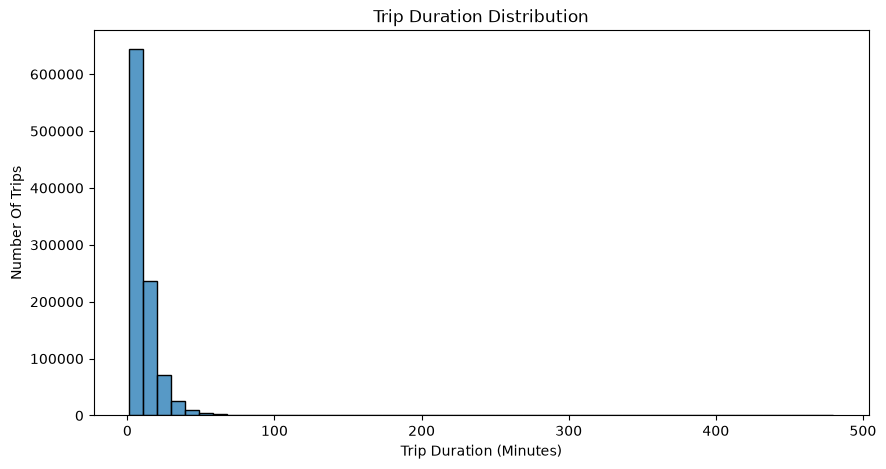

In [67]:
# Trip Duration Distribution

plt.figure(figsize=(10, 5))
sns.histplot(
    df["Trip_Duration_Minutes"],
    bins=50
)
plt.title("Trip Duration Distribution")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Number Of Trips")
plt.show()

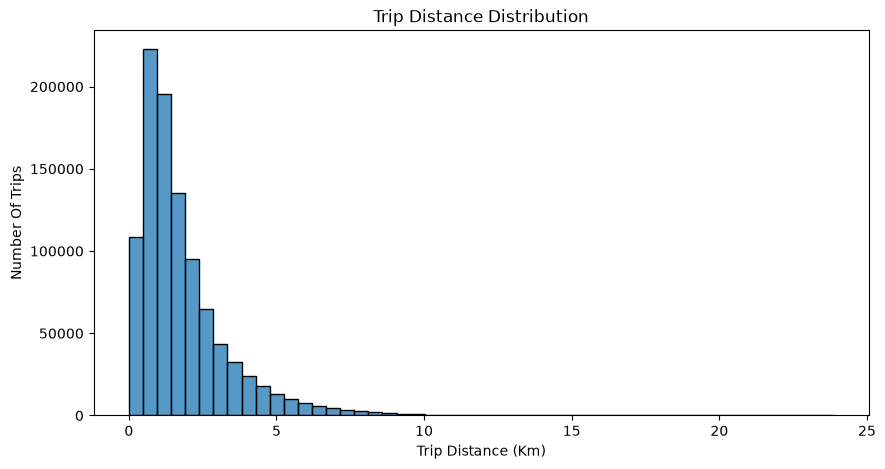

In [68]:
# Trip Distance Distribution

plt.figure(figsize=(10, 5))
sns.histplot(
    df["Trip_Distance_Km"],
    bins=50
)
plt.title("Trip Distance Distribution")
plt.xlabel("Trip Distance (Km)")
plt.ylabel("Number Of Trips")
plt.show()

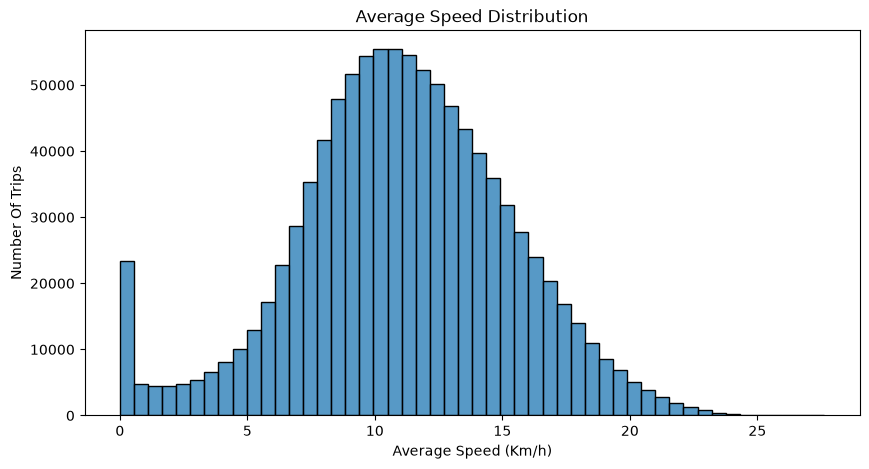

In [69]:
# Average Speed Distribution

plt.figure(figsize=(10, 5))
sns.histplot(
    df["Average_Speed_Kmh"],
    bins=50
)
plt.title("Average Speed Distribution")
plt.xlabel("Average Speed (Km/h)")
plt.ylabel("Number Of Trips")
plt.show()

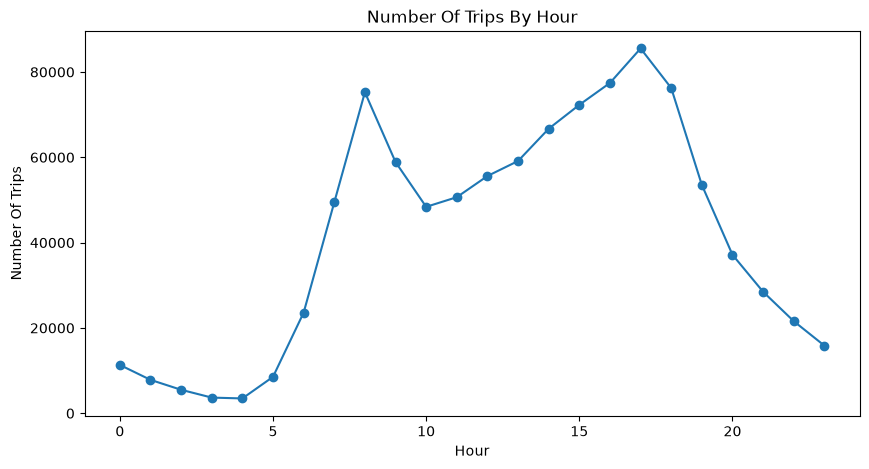

In [70]:
# Trips By Hour

Hourly_Trips = (
    df["Hour"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(10, 5))
plt.plot(
    Hourly_Trips.index,
    Hourly_Trips.values,
    marker="o"
)
plt.title("Number Of Trips By Hour")
plt.xlabel("Hour")
plt.ylabel("Number Of Trips")
plt.show()

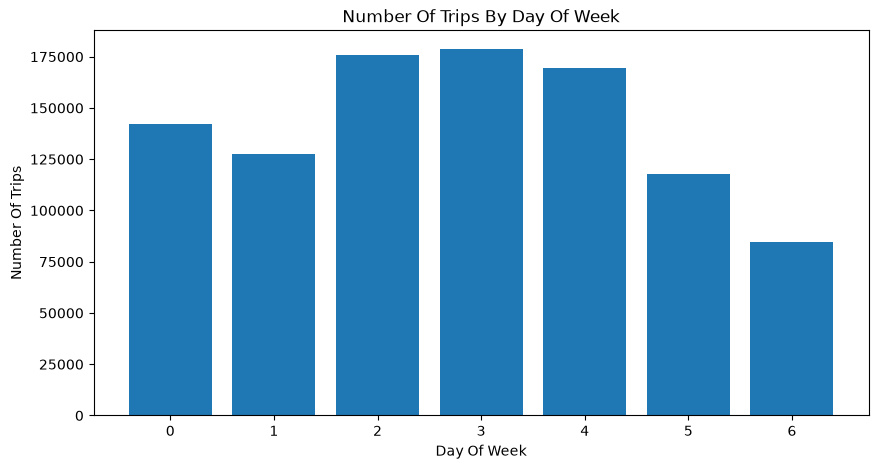

In [71]:
# Trips By Day Of Week

Day_Trips = (
    df["Day_Of_Week"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(10, 5))
plt.bar(
    Day_Trips.index,
    Day_Trips.values
)
plt.title("Number Of Trips By Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Number Of Trips")
plt.show()

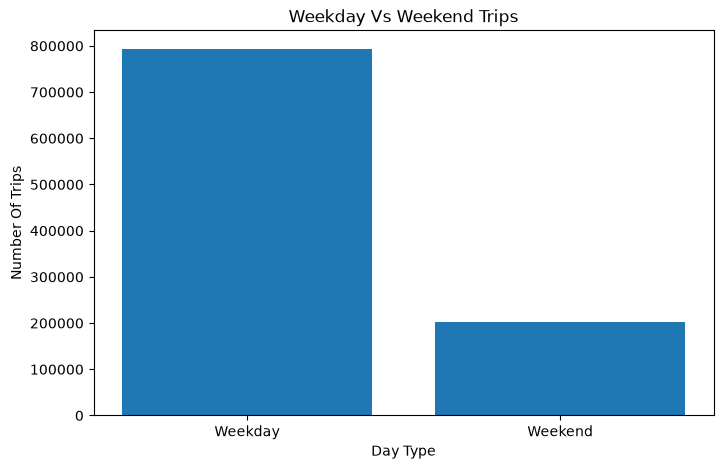

In [72]:
# Weekday Vs Weekend

Weekend_Trips = (
    df["Is_Weekend"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(8, 5))
plt.bar(
    ["Weekday", "Weekend"],
    Weekend_Trips.values
)
plt.title("Weekday Vs Weekend Trips")
plt.xlabel("Day Type")
plt.ylabel("Number Of Trips")
plt.show()

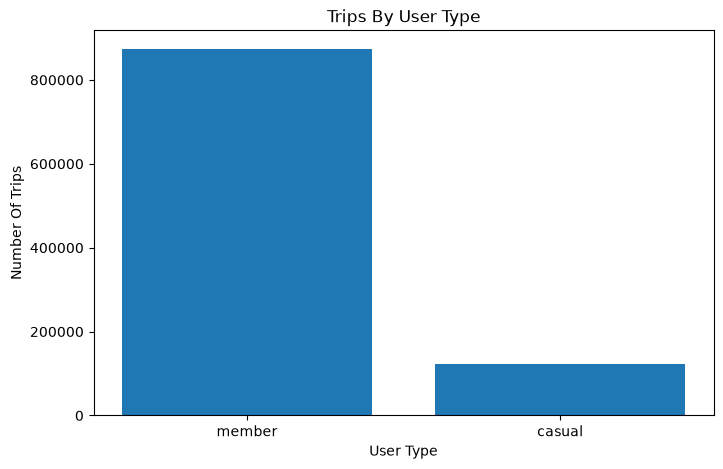

In [73]:
# User Type Distribution

User_Trips = (
    df["User_Type"]
    .value_counts()
)
plt.figure(figsize=(8, 5))
plt.bar(
    User_Trips.index,
    User_Trips.values
)
plt.title("Trips By User Type")
plt.xlabel("User Type")
plt.ylabel("Number Of Trips")
plt.show()

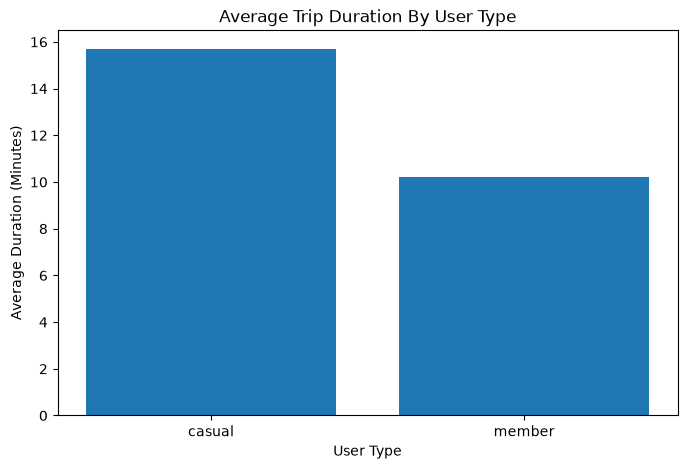

In [74]:
# Average Duration By User Type

Average_Duration_User = (
    df.groupby("User_Type")[
        "Trip_Duration_Minutes"
    ].mean()
)
plt.figure(figsize=(8, 5))
plt.bar(
    Average_Duration_User.index,
    Average_Duration_User.values
)
plt.title("Average Trip Duration By User Type")
plt.xlabel("User Type")
plt.ylabel("Average Duration (Minutes)")
plt.show()

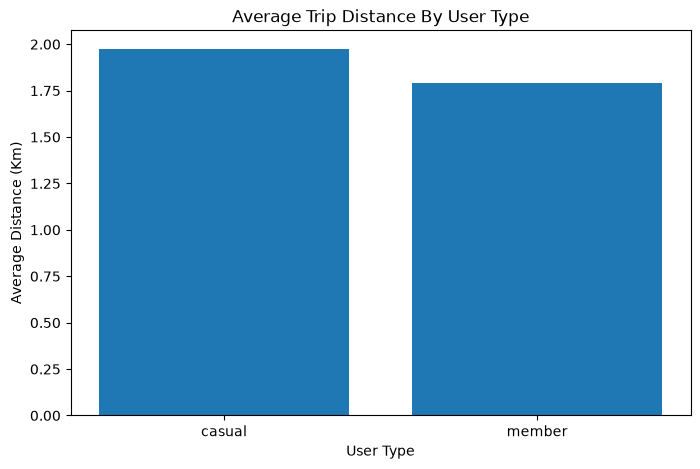

In [75]:
# Average Distance By User Type

Average_Distance_User = (
    df.groupby("User_Type")[
        "Trip_Distance_Km"
    ].mean()
)
plt.figure(figsize=(8, 5))
plt.bar(
    Average_Distance_User.index,
    Average_Distance_User.values
)
plt.title("Average Trip Distance By User Type")
plt.xlabel("User Type")
plt.ylabel("Average Distance (Km)")
plt.show()

In [76]:
# Top 20 Start Stations

Top_Start_Stations = (
    df["Start_Station"]
    .value_counts()
    .head(20)
)
Top_Start_Stations

Start_Station
W 21 St & 6 Ave               4166
1 Ave & E 68 St               3610
W 31 St & 7 Ave               3072
E 33 St & 1 Ave               3047
8 Ave & W 31 St               2925
Broadway & W 58 St            2873
Ave A & E 14 St               2838
Lafayette St & E 8 St         2837
Broadway & W 25 St            2811
Broadway & E 14 St            2797
W 41 St & 8 Ave               2704
W 44 St & 11 Ave              2697
E 17 St & Broadway            2636
7 Ave & Central Park South    2554
Clinton St & Grand St         2550
W 20 St & 10 Ave              2521
Amsterdam Ave & W 73 St       2513
University Pl & E 14 St       2474
8 Ave & W 16 St               2472
W 24 St & 7 Ave               2450
Name: count, dtype: int64

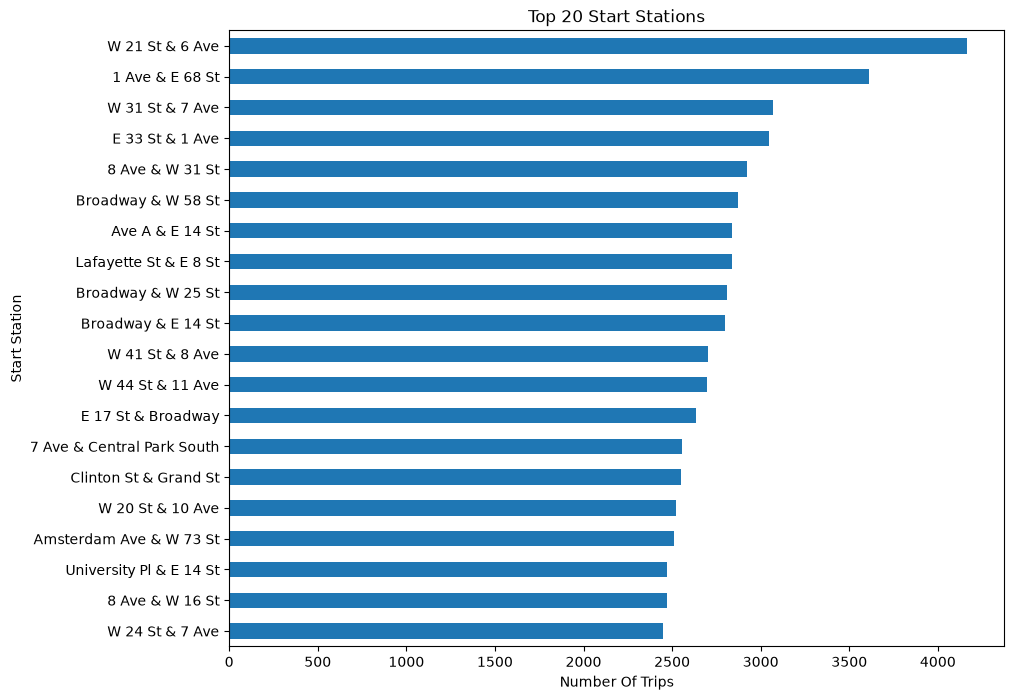

In [77]:
# Plot Top 20 Start Stations

plt.figure(figsize=(10, 8))
Top_Start_Stations.sort_values().plot(
    kind="barh"
)
plt.title("Top 20 Start Stations")
plt.xlabel("Number Of Trips")
plt.ylabel("Start Station")
plt.show()

In [78]:
# Top 20 End Stations

Top_End_Stations = (
    df["End_Station"]
    .value_counts()
    .head(20)
)
Top_End_Stations

End_Station
W 24 St & 7 Ave       4351
1 Ave & E 62 St       4137
Broadway & W 29 St    3867
E 77 St & 1 Ave       3832
W 21 St & 6 Ave       3725
E 72 St & York Ave    3407
E 14 St & 1 Ave       3383
1 Ave & E 68 St       3312
E 25 St & 2 Ave       3149
E 48 St & 5 Ave       3082
W 22 St & 8 Ave       3046
1 Ave & E 39 St       2968
W 56 St & 8 Ave       2868
W 31 St & 7 Ave       2799
E 33 St & 1 Ave       2794
E 10 St & 2 Ave       2778
8 Ave & W 31 St       2751
W 51 St & 6 Ave       2721
11 Ave & W 27 St      2714
Broadway & E 14 St    2673
Name: count, dtype: int64

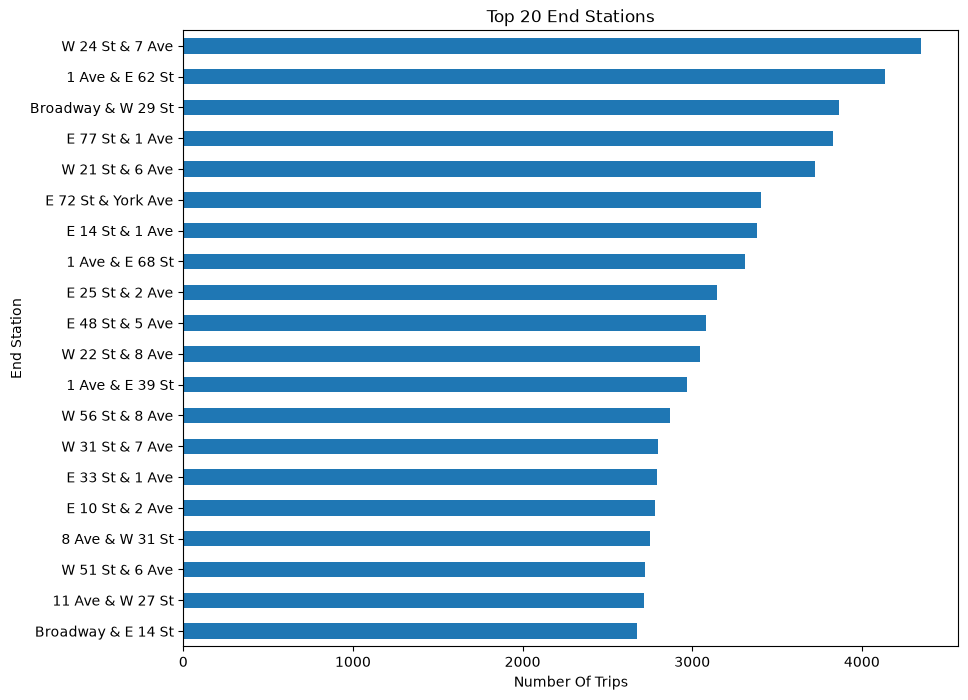

In [79]:
# Plot Top 20 End Stations

plt.figure(figsize=(10, 8))
Top_End_Stations.sort_values().plot(
    kind="barh"
)
plt.title("Top 20 End Stations")
plt.xlabel("Number Of Trips")
plt.ylabel("End Station")
plt.show()

In [80]:
# Top Origin Destination Routes

Top_Routes = (
    df.groupby(
        ["Start_Station", "End_Station"]
    )
    .size()
    .reset_index(
        name="Trip_Count"
    )
    .sort_values(
        "Trip_Count",
        ascending=False
    )
    .head(20)
)

Top_Routes

,Start_Station,End_Station,Trip_Count
37257,7 Ave & Central Park South,7 Ave & Central Park South,296
146140,Franklin St & Dupont St,Vernon Blvd & 50 Ave,292
254798,W 41 St & 8 Ave,E 48 St & 5 Ave,278
79838,Central Park S & 6 Ave,Central Park S & 6 Ave,261
199946,North Moore St & Greenwich St,Vesey St & Church St,203
9461,2 Ave & E 72 St,E 72 St & York Ave,202
139953,Eagle St & Manhattan Ave,Vernon Blvd & 50 Ave,200
246837,W 22 St & 10 Ave,W 22 St & 8 Ave,196
133466,E 77 St & 3 Ave,E 77 St & 1 Ave,194
236539,Vesey St & Church St,North Moore St & Greenwich St,191


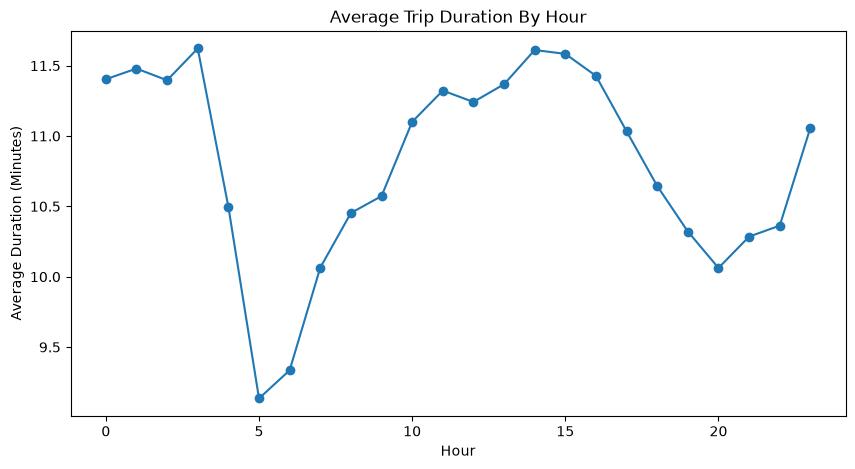

In [81]:
# Average Duration By Hour

Average_Duration_Hour = (
    df.groupby("Hour")[
        "Trip_Duration_Minutes"
    ].mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    Average_Duration_Hour.index,
    Average_Duration_Hour.values,
    marker="o"
)

plt.title("Average Trip Duration By Hour")
plt.xlabel("Hour")
plt.ylabel("Average Duration (Minutes)")

plt.show()

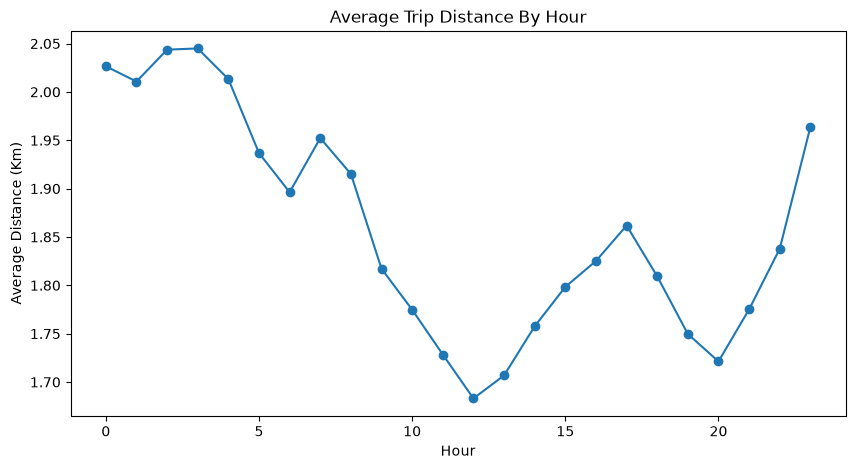

In [82]:
# Average Distance By Hour

Average_Distance_Hour = (
    df.groupby("Hour")[
        "Trip_Distance_Km"
    ].mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    Average_Distance_Hour.index,
    Average_Distance_Hour.values,
    marker="o"
)

plt.title("Average Trip Distance By Hour")
plt.xlabel("Hour")
plt.ylabel("Average Distance (Km)")

plt.show()

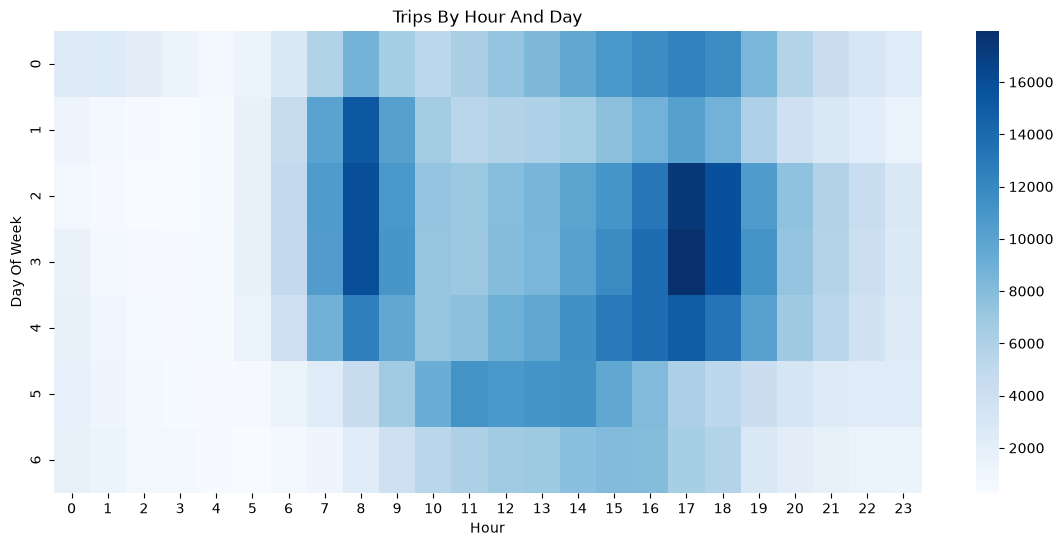

In [83]:
# Hour Vs Day Heatmap

Hour_Day = pd.crosstab(
    df["Day_Of_Week"],
    df["Hour"]
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    Hour_Day,
    cmap="Blues"
)

plt.title("Trips By Hour And Day")
plt.xlabel("Hour")
plt.ylabel("Day Of Week")

plt.show()

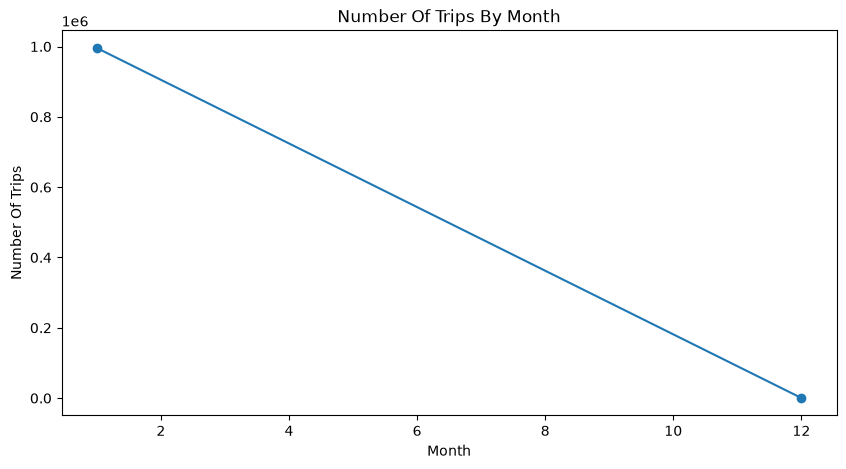

In [84]:
# Trips By Month

Monthly_Trips = (
    df["Month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    Monthly_Trips.index,
    Monthly_Trips.values,
    marker="o"
)

plt.title("Number Of Trips By Month")
plt.xlabel("Month")
plt.ylabel("Number Of Trips")

plt.show()

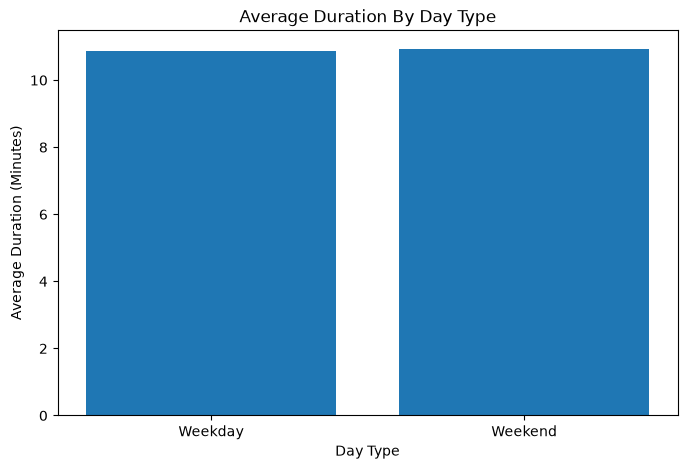

In [85]:
# Average Duration By Day Type

Average_Duration_Day = (
    df.groupby("Is_Weekend")[
        "Trip_Duration_Minutes"
    ].mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Weekday", "Weekend"],
    Average_Duration_Day.values
)

plt.title("Average Duration By Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Duration (Minutes)")

plt.show()

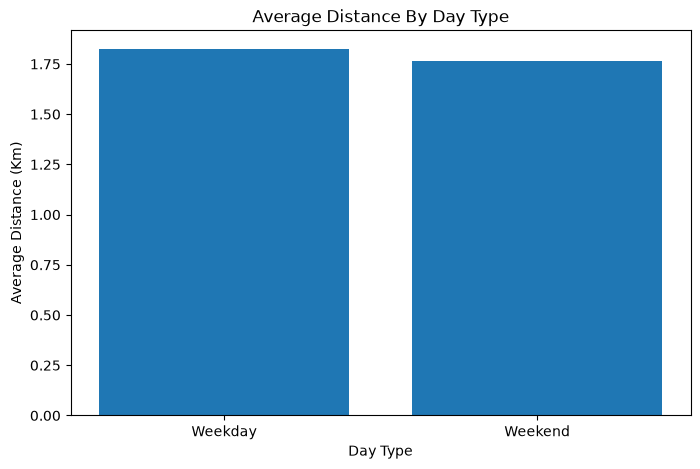

In [86]:
# Average Distance By Day Type

Average_Distance_Day = (
    df.groupby("Is_Weekend")[
        "Trip_Distance_Km"
    ].mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Weekday", "Weekend"],
    Average_Distance_Day.values
)

plt.title("Average Distance By Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Distance (Km)")

plt.show()

In [87]:
# User Type Vs Weekend

User_Weekend = pd.crosstab(
    df["User_Type"],
    df["Is_Weekend"]
)

User_Weekend.columns = [
    "Weekday",
    "Weekend"
]

User_Weekend

,Weekday,Weekend
User_Type,,
casual,92358,29679
member,701241,172841


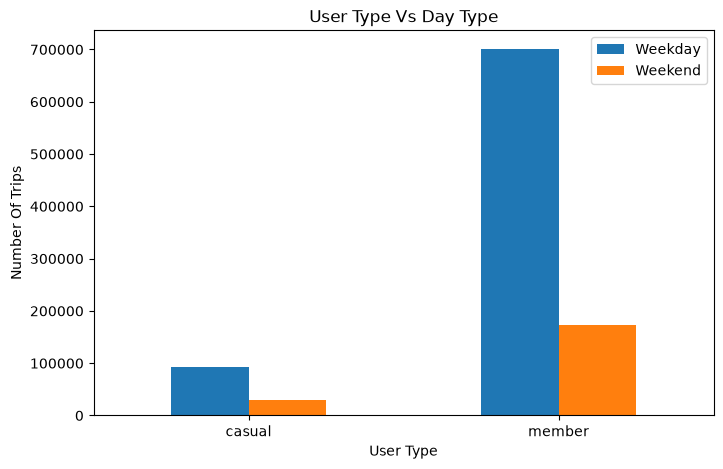

In [88]:
# Plot User Type Vs Weekend

User_Weekend.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("User Type Vs Day Type")
plt.xlabel("User Type")
plt.ylabel("Number Of Trips")

plt.xticks(rotation=0)

plt.show()

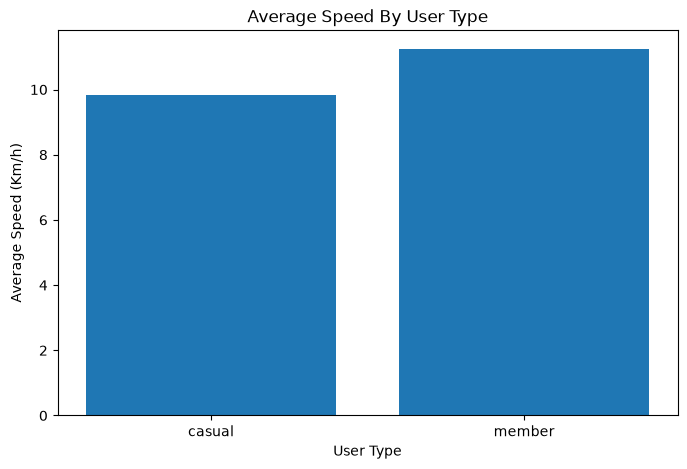

In [89]:
# Average Speed By User Type

Average_Speed_User = (
    df.groupby("User_Type")[
        "Average_Speed_Kmh"
    ].mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    Average_Speed_User.index,
    Average_Speed_User.values
)

plt.title("Average Speed By User Type")
plt.xlabel("User Type")
plt.ylabel("Average Speed (Km/h)")

plt.show()

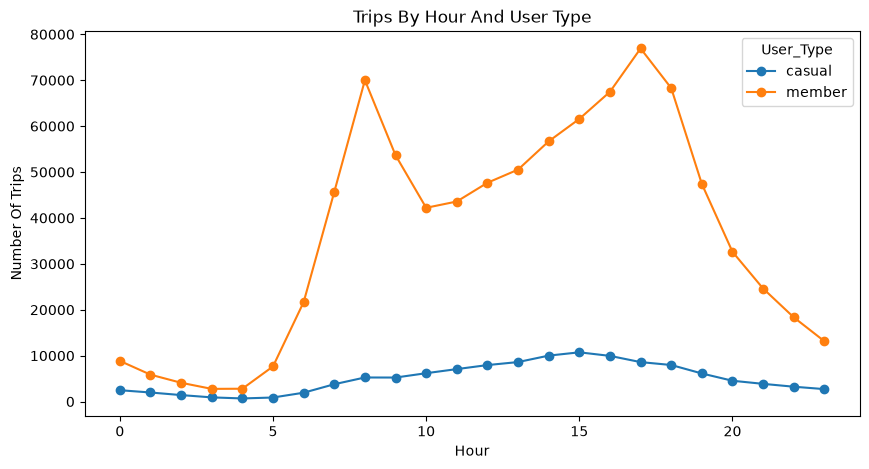

In [90]:
# Trip Count By Hour And User Type

Hour_User = pd.crosstab(
    df["Hour"],
    df["User_Type"]
)

Hour_User.plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Trips By Hour And User Type")
plt.xlabel("Hour")
plt.ylabel("Number Of Trips")

plt.show()

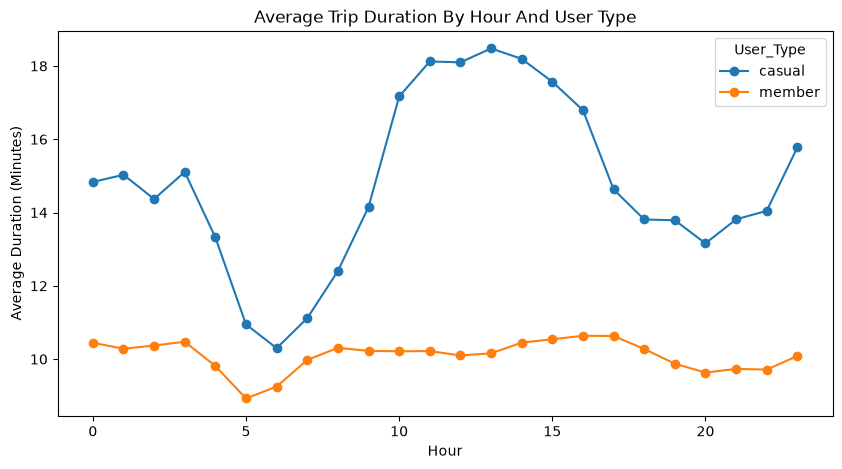

In [91]:
# Average Duration By Hour And User Type

Hour_User_Duration = (
    df.groupby(
        ["Hour", "User_Type"]
    )["Trip_Duration_Minutes"]
    .mean()
    .unstack()
)

Hour_User_Duration.plot(
    figsize=(10, 5),
    marker="o"
)

plt.title(
    "Average Trip Duration By Hour And User Type"
)

plt.xlabel("Hour")
plt.ylabel("Average Duration (Minutes)")

plt.show()

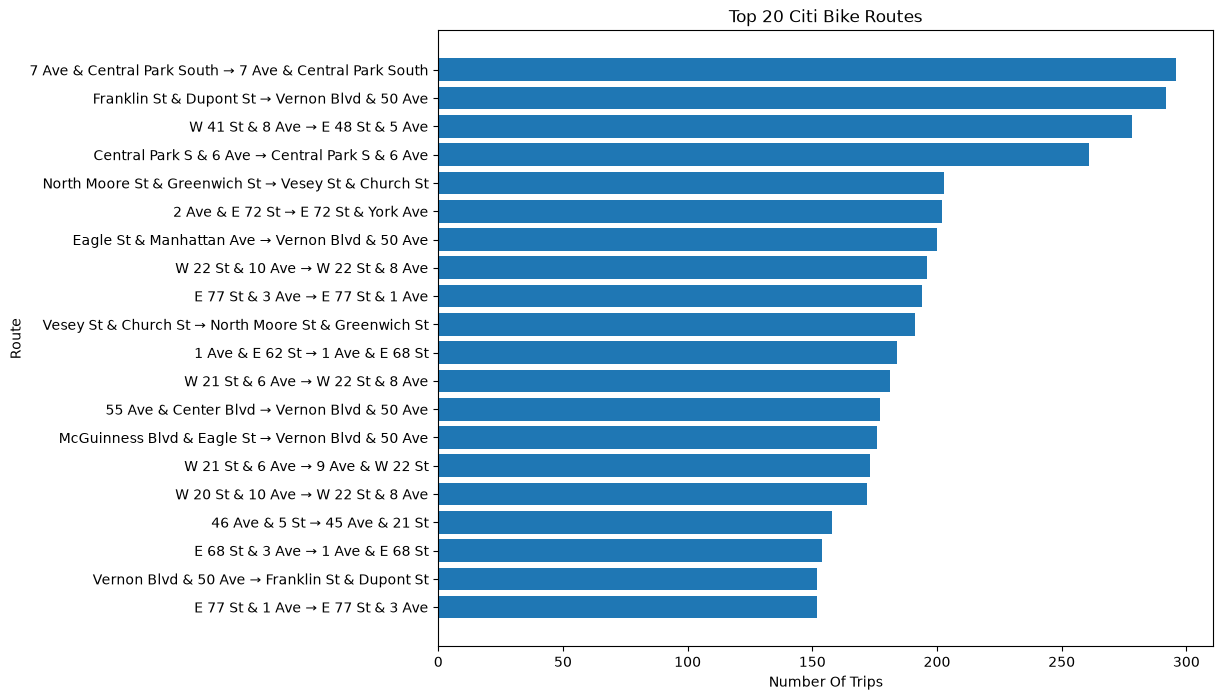

In [92]:
# Top 20 Routes

Top_Routes["Route"] = (
    Top_Routes["Start_Station"]
    + " → "
    + Top_Routes["End_Station"]
)

plt.figure(figsize=(10, 8))

plt.barh(
    Top_Routes["Route"][::-1],
    Top_Routes["Trip_Count"][::-1]
)

plt.title("Top 20 Citi Bike Routes")
plt.xlabel("Number Of Trips")
plt.ylabel("Route")

plt.show()

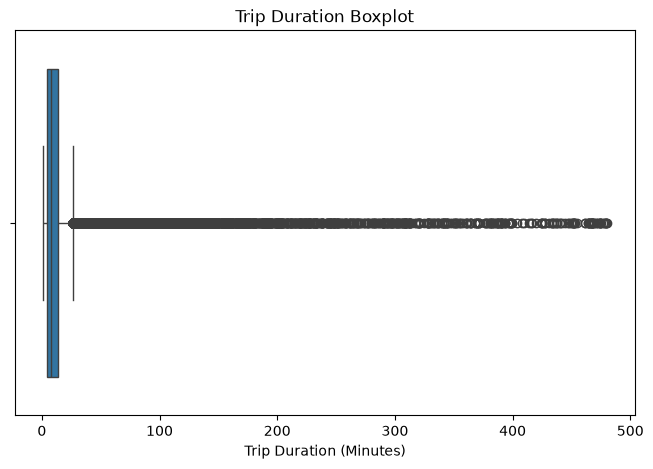

In [93]:
# Trip Duration Boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Trip_Duration_Minutes"]
)

plt.title("Trip Duration Boxplot")
plt.xlabel("Trip Duration (Minutes)")

plt.show()

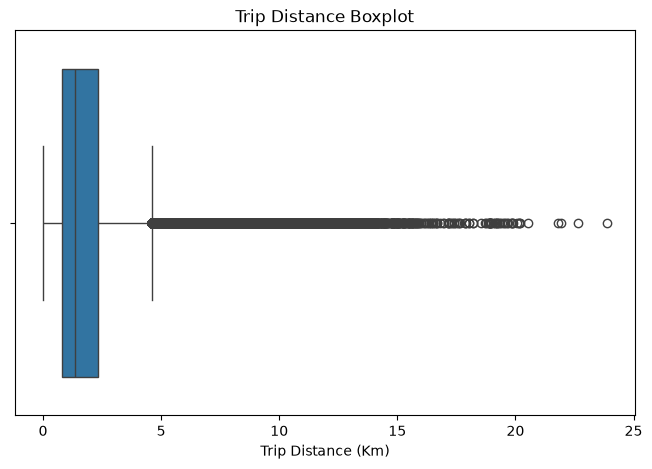

In [94]:
# Trip Distance Boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Trip_Distance_Km"]
)

plt.title("Trip Distance Boxplot")
plt.xlabel("Trip Distance (Km)")

plt.show()

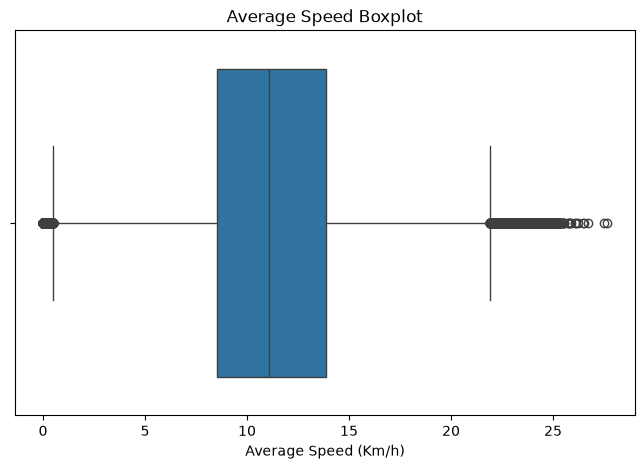

In [95]:
# Average Speed Boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Average_Speed_Kmh"]
)

plt.title("Average Speed Boxplot")
plt.xlabel("Average Speed (Km/h)")

plt.show()

In [96]:
# Correlation Matrix

Correlation_Columns = [
    "Trip_Duration_Minutes",
    "Trip_Distance_Km",
    "Average_Speed_Kmh",
    "Hour",
    "Day_Of_Week",
    "Month",
    "Year",
    "Is_Weekend"
]

Correlation_Matrix = df[
    Correlation_Columns
].corr()

Correlation_Matrix

,Trip_Duration_Minutes,Trip_Distance_Km,Average_Speed_Kmh,Hour,Day_Of_Week,Month,Year,Is_Weekend
Trip_Duration_Minutes,1.000000,0.510295,-0.229749,0.003530,-0.009932,0.056708,-0.056708,0.001966
Trip_Distance_Km,0.510295,1.000000,0.367490,-0.022243,-0.011473,0.010251,-0.010251,-0.015287
Average_Speed_Kmh,-0.229749,0.367490,1.000000,-0.068493,-0.004337,-0.021469,0.021469,-0.015405
Hour,0.003530,-0.022243,-0.068493,1.000000,0.014387,0.035489,-0.035489,-0.016169
Day_Of_Week,-0.009932,-0.011473,-0.004337,0.014387,1.000000,0.032628,-0.032628,0.723206
Month,0.056708,0.010251,-0.021469,0.035489,0.032628,1.000000,-1.000000,0.036900
Year,-0.056708,-0.010251,0.021469,-0.035489,-0.032628,-1.000000,1.000000,-0.036900
Is_Weekend,0.001966,-0.015287,-0.015405,-0.016169,0.723206,0.036900,-0.036900,1.000000


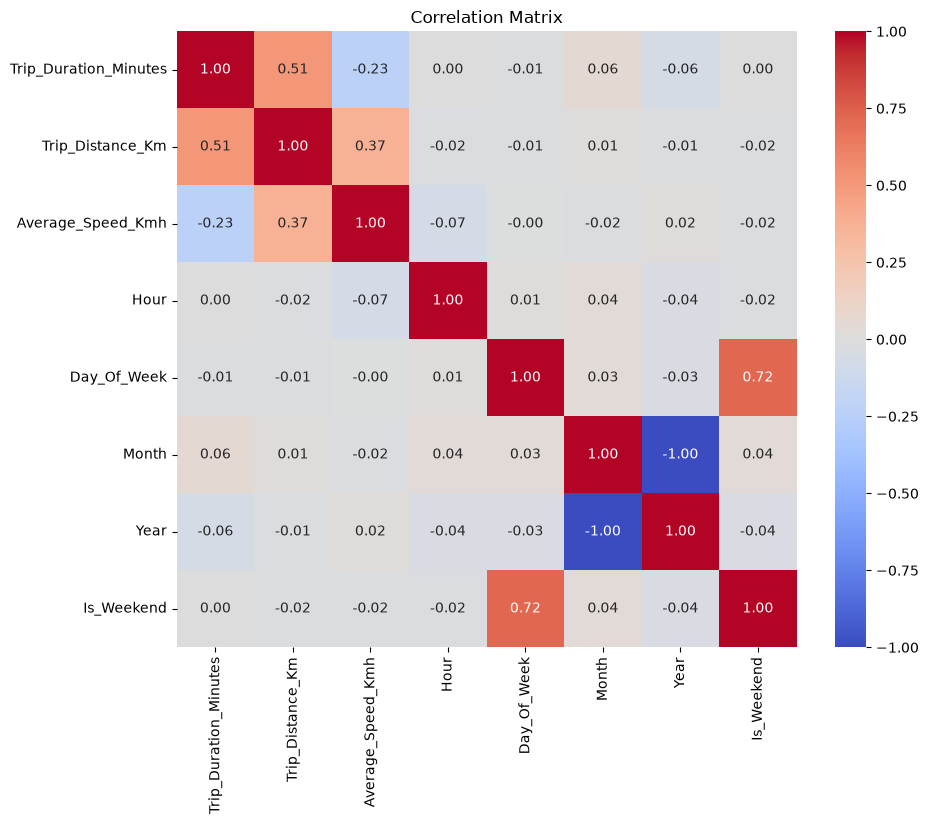

In [97]:
# Plot Correlation Matrix

plt.figure(figsize=(10, 8))

sns.heatmap(
    Correlation_Matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# Final EDA Summary

print("Total Trips:", len(df))

print(
    "Average Trip Duration:",
    df["Trip_Duration_Minutes"].mean()
)

print(
    "Average Trip Distance:",
    df["Trip_Distance_Km"].mean()
)

print(
    "Average Speed:",
    df["Average_Speed_Kmh"].mean()
)

print(
    "Most Common User Type:",
    df["User_Type"].mode()[0]
)

print(
    "Most Common Start Station:",
    df["Start_Station"].mode()[0]
)

print(
    "Most Common End Station:",
    df["End_Station"].mode()[0]
)

Total Trips: 996119
Average Trip Duration: 10.88664423653198
Average Trip Distance: 1.813124017476208
Average Speed: 11.073981094844235
Most Common User Type: member
Most Common Start Station: W 21 St & 6 Ave
Most Common End Station: W 24 St & 7 Ave
